Importem llibreries y gràfica

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuració estètica
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

Importem DF

In [3]:
RRHH = pd.read_csv(r"C:\Users\Lucan Vieira\ProjecteData\Equip_15\Scripts\RRHH_220925_clean.csv")

=== MATRIU DE CORRELACIONS DE SPEARMAN ===
Variables analitzades: ['Son', 'Social_drinker', 'Age', 'Reason_absence', 'Social_smoker', 'Pet', 'Weight', 'Height', 'Body_mass_index']


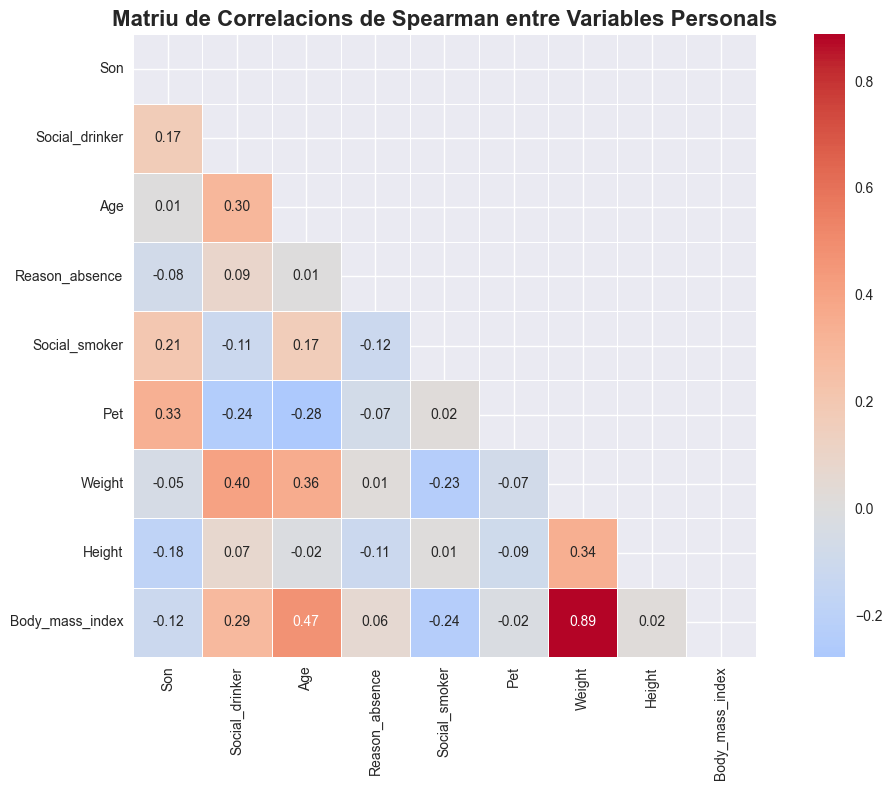


=== COMPARACIÓ PEARSON vs SPEARMAN ===


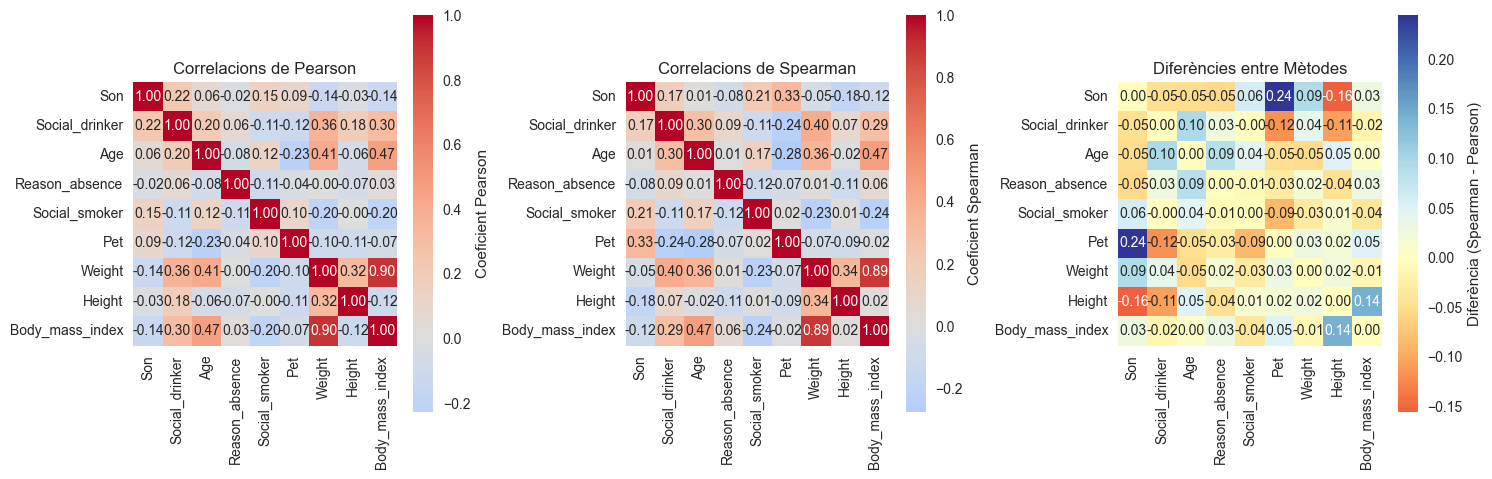


=== CORRELACIONS DE SPEARMAN AMB ABSENTEEISM_HOURS ===
Correlacions de Spearman amb hores d'absentisme:
Son: 0.132
Social_drinker: 0.110
Height: 0.068
Social_smoker: -0.004
Weight: -0.010
Pet: -0.016
Body_mass_index: -0.060
Age: -0.065
Reason_absence: -0.201


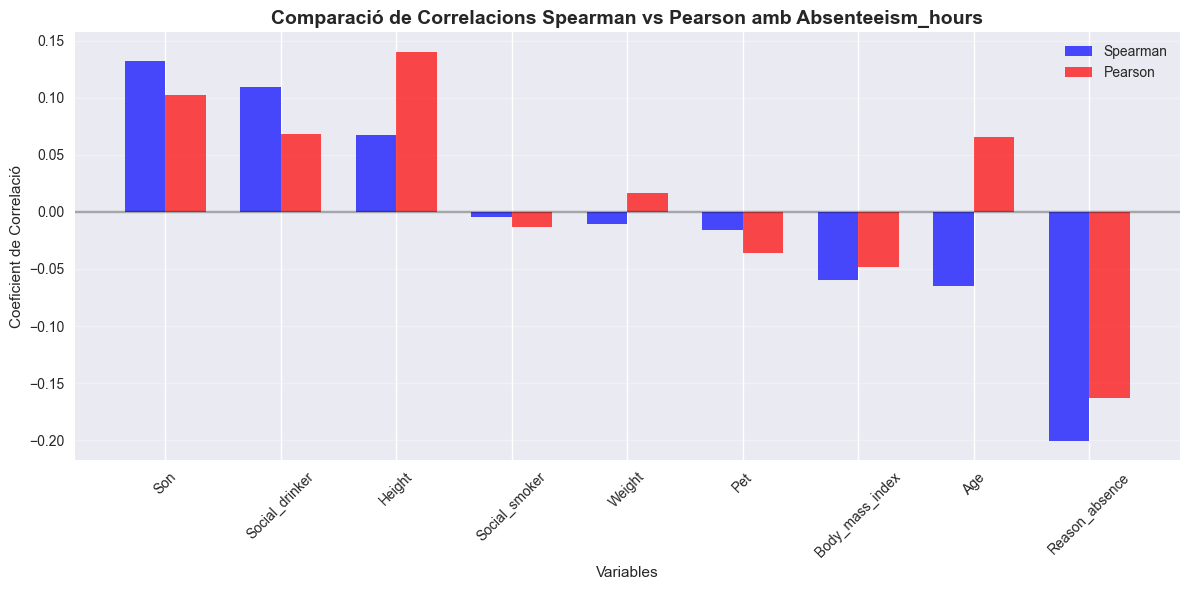


=== SIGNIFICACIÓ ESTADÍSTICA DE CORRELACIONS SPEARMAN ===


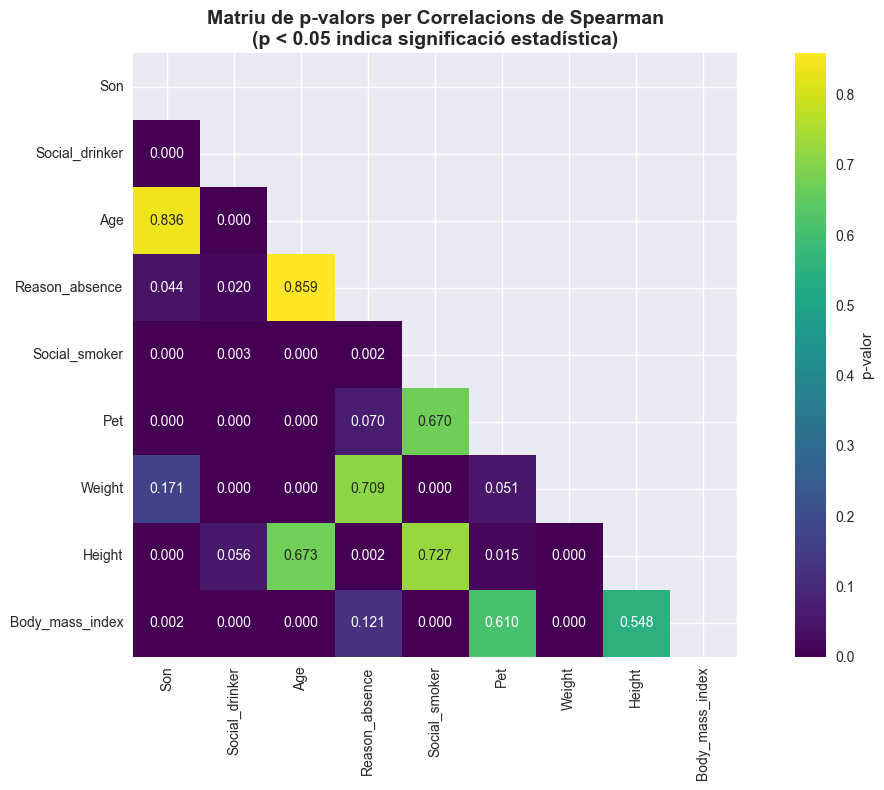


=== CORRELACIONS SIGNIFICATIVES (p < 0.05) ===
Correlacions significatives (p < 0.05):
Weight - Body_mass_index: 0.887 *** (p = 0.0000)
Age - Body_mass_index: 0.470 *** (p = 0.0000)
Social_drinker - Weight: 0.402 *** (p = 0.0000)
Age - Weight: 0.359 *** (p = 0.0000)
Weight - Height: 0.341 *** (p = 0.0000)
Son - Pet: 0.335 *** (p = 0.0000)
Social_drinker - Age: 0.296 *** (p = 0.0000)
Social_drinker - Body_mass_index: 0.289 *** (p = 0.0000)
Age - Pet: -0.277 *** (p = 0.0000)
Social_drinker - Pet: -0.244 *** (p = 0.0000)
Social_smoker - Body_mass_index: -0.236 *** (p = 0.0000)
Social_smoker - Weight: -0.235 *** (p = 0.0000)
Son - Social_smoker: 0.209 *** (p = 0.0000)
Son - Height: -0.181 *** (p = 0.0000)
Son - Social_drinker: 0.170 *** (p = 0.0000)
Age - Social_smoker: 0.166 *** (p = 0.0000)
Reason_absence - Social_smoker: -0.116 ** (p = 0.0021)
Son - Body_mass_index: -0.116 ** (p = 0.0021)
Reason_absence - Height: -0.114 ** (p = 0.0024)
Social_drinker - Social_smoker: -0.113 ** (p = 0.0

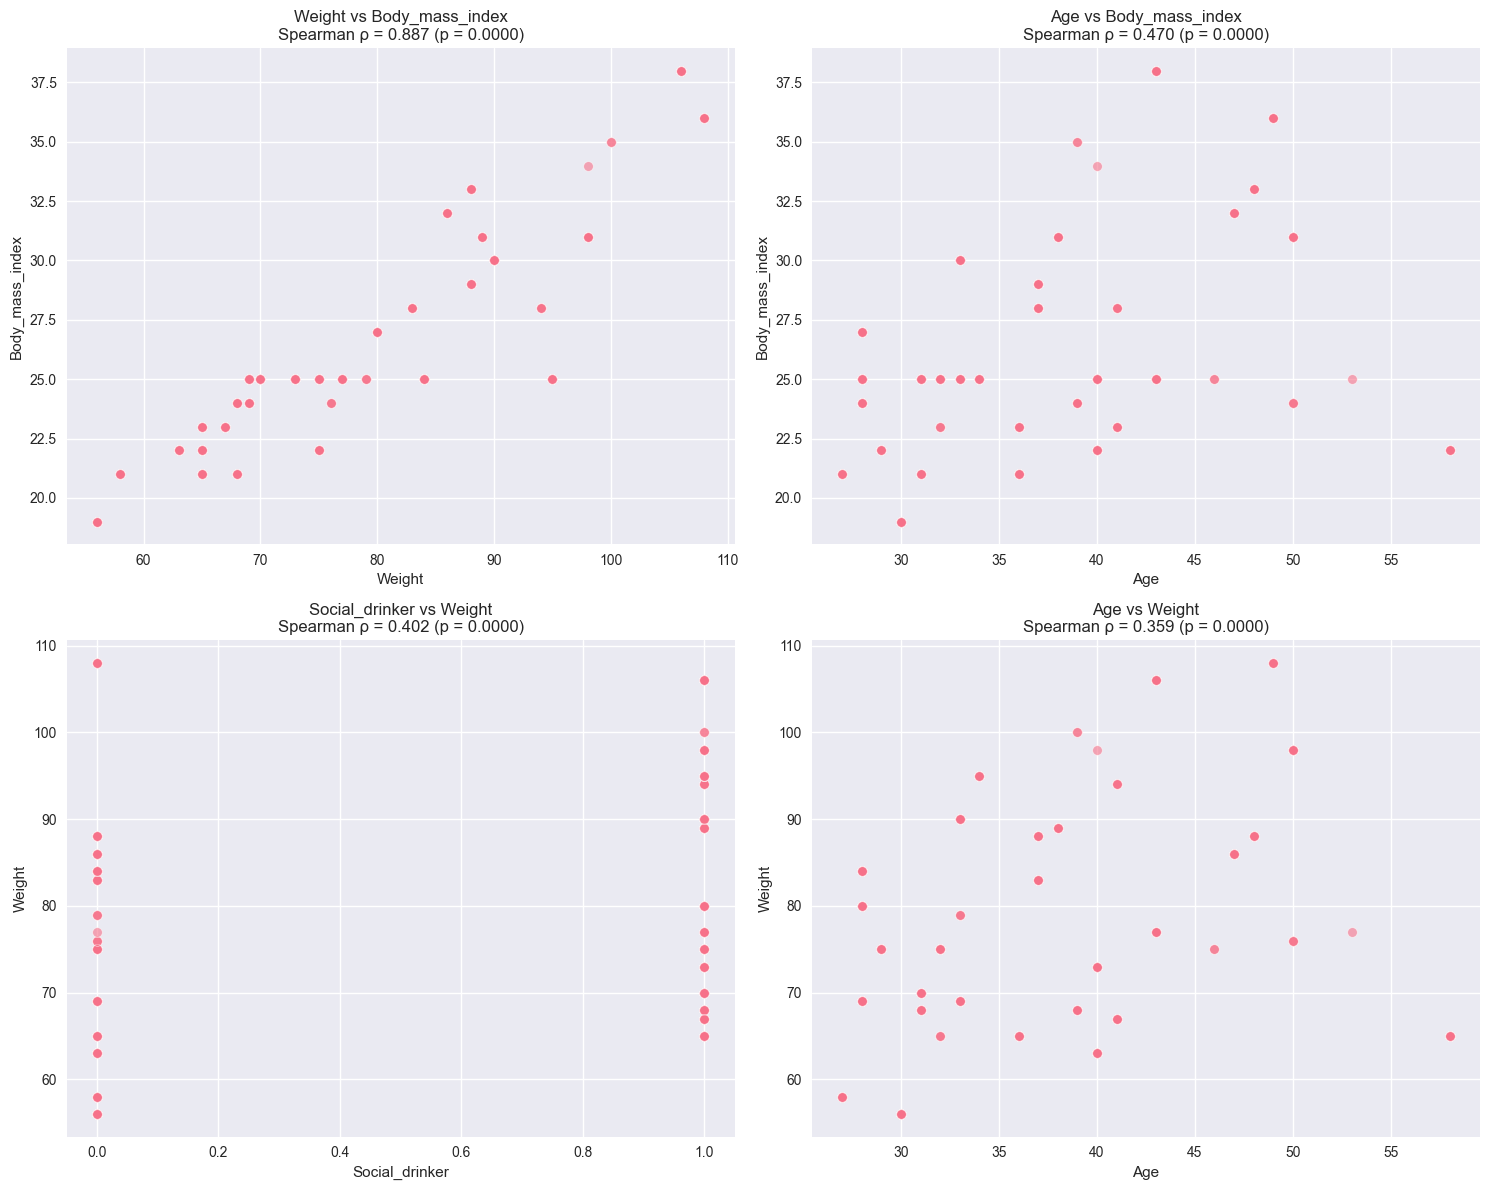

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr

# 1. MATRIU DE CORRELACIONS DE SPEARMAN
print("=== MATRIU DE CORRELACIONS DE SPEARMAN ===")
variables_personal = ['Son', 'Social_drinker', 'Age', 'Reason_absence', 
                     'Social_smoker', 'Pet', 'Weight', 'Height', 'Body_mass_index']

# Verifica quines variables existeixen
variables_existents = [var for var in variables_personal if var in RRHH.columns]
print(f"Variables analitzades: {variables_existents}")

# Calcula matriu de correlacions de Spearman
correlacions_spearman = RRHH[variables_existents].corr(method='spearman')

# Visualització
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(correlacions_spearman, dtype=bool))  # Màscara per triangle superior
sns.heatmap(correlacions_spearman, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5, mask=mask)
plt.title('Matriu de Correlacions de Spearman entre Variables Personals', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. COMPARACIÓ ENTRE PEARSON I SPEARMAN
print("\n=== COMPARACIÓ PEARSON vs SPEARMAN ===")

# Calcula ambdós mètodes
correlacions_pearson = RRHH[variables_existents].corr(method='pearson')

# Diferències entre mètodes
diferencies = correlacions_spearman - correlacions_pearson

plt.figure(figsize=(15, 5))

# Subplot 1: Pearson
plt.subplot(1, 3, 1)
sns.heatmap(correlacions_pearson, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, cbar_kws={'label': 'Coeficient Pearson'})
plt.title('Correlacions de Pearson')

# Subplot 2: Spearman
plt.subplot(1, 3, 2)
sns.heatmap(correlacions_spearman, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, cbar_kws={'label': 'Coeficient Spearman'})
plt.title('Correlacions de Spearman')

# Subplot 3: Diferències
plt.subplot(1, 3, 3)
sns.heatmap(diferencies, annot=True, cmap='RdYlBu', center=0, fmt='.2f', 
            square=True, cbar_kws={'label': 'Diferència (Spearman - Pearson)'})
plt.title('Diferències entre Mètodes')

plt.tight_layout()
plt.show()

# 3. CORRELACIONS DE SPEARMAN AMB ABSENTISME
if 'Absenteeism_hours' in RRHH.columns:
    print("\n=== CORRELACIONS DE SPEARMAN AMB ABSENTEEISM_HOURS ===")
    
    # Calcula correlacions de Spearman amb la variable objectiu
    variables_amb_absentisme = variables_existents + ['Absenteeism_hours']
    correlacions_spearman_abs = RRHH[variables_amb_absentisme].corr(method='spearman')
    
    # Extrau només les correlacions amb absentisme
    corr_spearman_amb_absentisme = correlacions_spearman_abs['Absenteeism_hours'].drop('Absenteeism_hours').sort_values(ascending=False)
    
    print("Correlacions de Spearman amb hores d'absentisme:")
    for var, corr in corr_spearman_amb_absentisme.items():
        print(f"{var}: {corr:.3f}")
    
    # Gràfic de barres comparatiu
    if len(variables_existents) > 0:
        # Calcula també Pearson per comparar
        correlacions_pearson_abs = RRHH[variables_amb_absentisme].corr(method='pearson')
        corr_pearson_amb_absentisme = correlacions_pearson_abs['Absenteeism_hours'].drop('Absenteeism_hours')
        
        # Crea DataFrame comparatiu
        df_comparacio = pd.DataFrame({
            'Spearman': corr_spearman_amb_absentisme,
            'Pearson': corr_pearson_amb_absentisme
        }).sort_values('Spearman', ascending=False)
        
        # Gràfic comparatiu
        plt.figure(figsize=(12, 6))
        x = np.arange(len(df_comparacio))
        width = 0.35
        
        plt.bar(x - width/2, df_comparacio['Spearman'], width, label='Spearman', alpha=0.7, color='blue')
        plt.bar(x + width/2, df_comparacio['Pearson'], width, label='Pearson', alpha=0.7, color='red')
        
        plt.xlabel('Variables')
        plt.ylabel('Coeficient de Correlació')
        plt.title('Comparació de Correlacions Spearman vs Pearson amb Absenteeism_hours', 
                 fontsize=14, fontweight='bold')
        plt.xticks(x, df_comparacio.index, rotation=45)
        plt.legend()
        plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

# 4. TEST DE SIGNIFICACIÓ ESTADÍSTICA PER SPEARMAN
print("\n=== SIGNIFICACIÓ ESTADÍSTICA DE CORRELACIONS SPEARMAN ===")

# Realitza tests de significació per a cada parell de variables
n_vars = len(variables_existents)
matriu_significacio = np.zeros((n_vars, n_vars))
matriu_p_valors = np.zeros((n_vars, n_vars))

for i, var1 in enumerate(variables_existents):
    for j, var2 in enumerate(variables_existents):
        if i <= j:  # Evita càlculs duplicats
            corr, p_value = spearmanr(RRHH[var1], RRHH[var2], nan_policy='omit')
            matriu_significacio[i, j] = corr
            matriu_p_valors[i, j] = p_value
            # Omple la part simètrica
            matriu_significacio[j, i] = corr
            matriu_p_valors[j, i] = p_value

# Converteix a DataFrame per millor visualització
df_spearman_stats = pd.DataFrame(matriu_significacio, 
                                index=variables_existents, 
                                columns=variables_existents)

df_p_values = pd.DataFrame(matriu_p_valors, 
                          index=variables_existents, 
                          columns=variables_existents)

# Visualització de p-valors
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(df_p_values, dtype=bool))
sns.heatmap(df_p_values, annot=True, cmap='viridis', fmt='.3f', 
            square=True, mask=mask, cbar_kws={'label': 'p-valor'})
plt.title('Matriu de p-valors per Correlacions de Spearman\n(p < 0.05 indica significació estadística)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. RESUM DE CORRELACIONS SIGNIFICATIVES
print("\n=== CORRELACIONS SIGNIFICATIVES (p < 0.05) ===")
correlacions_significatives = []

for i, var1 in enumerate(variables_existents):
    for j, var2 in enumerate(variables_existents):
        if i < j:  # Evita duplicats i la diagonal
            corr = df_spearman_stats.iloc[i, j]
            p_val = df_p_values.iloc[i, j]
            if p_val < 0.05:
                correlacions_significatives.append((var1, var2, corr, p_val))

# Ordena per força de correlació
correlacions_significatives.sort(key=lambda x: abs(x[2]), reverse=True)

print("Correlacions significatives (p < 0.05):")
for var1, var2, corr, p_val in correlacions_significatives:
    significacio = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
    print(f"{var1} - {var2}: {corr:.3f} {significacio} (p = {p_val:.4f})")

# 6. GRÀFIC DE DISPERSIÓ PER CORRELACIONS MÉS FORTES
if len(correlacions_significatives) > 0:
    print("\n=== GRÀFICS DE DISPERSIÓ PER CORRELACIONS FORTES ===")
    # Selecciona les 4 correlacions més fortes
    top_correlacions = correlacions_significatives[:4]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.ravel()
    
    for idx, (var1, var2, corr, p_val) in enumerate(top_correlacions):
        if idx < 4:
            # Gràfic de dispersió
            sns.scatterplot(data=RRHH, x=var1, y=var2, ax=axes[idx], alpha=0.6)
            axes[idx].set_title(f'{var1} vs {var2}\nSpearman ρ = {corr:.3f} (p = {p_val:.4f})')
            axes[idx].set_xlabel(var1)
            axes[idx].set_ylabel(var2)
    
    plt.tight_layout()
    plt.show()

=== INFORMACIÓN DEL DATASET ===
Total de filas en el dataset: 706
Columnas disponibles: ['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons', 'Transportation_expense', 'Distance_Residence_Work', 'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure', 'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height', 'Body_mass_index', 'Absenteeism_hours', 'Education_numeric', 'Month_absence_order', 'Day_week_order', 'Seasons_order']
Columna de ID encontrada: ID
Número único de empleados: 36

=== CREANDO DATASET ÚNICO POR EMPLEADO ===
🚫 Variable excluida: Reason_absence (para evitar correlación artificial)
Variables analizadas: ['Son', 'Social_drinker', 'Education', 'Age', 'Social_smoker', 'Pet', 'Weight', 'Height', 'Body_mass_index']
Procesando variables por empleado...
  - Procesando Son...
  - Procesando Social_drinker...
  - Procesando Education...
  - Procesando Age...
  - Procesando Social_smoker...
  - Procesando Pet...
  - 

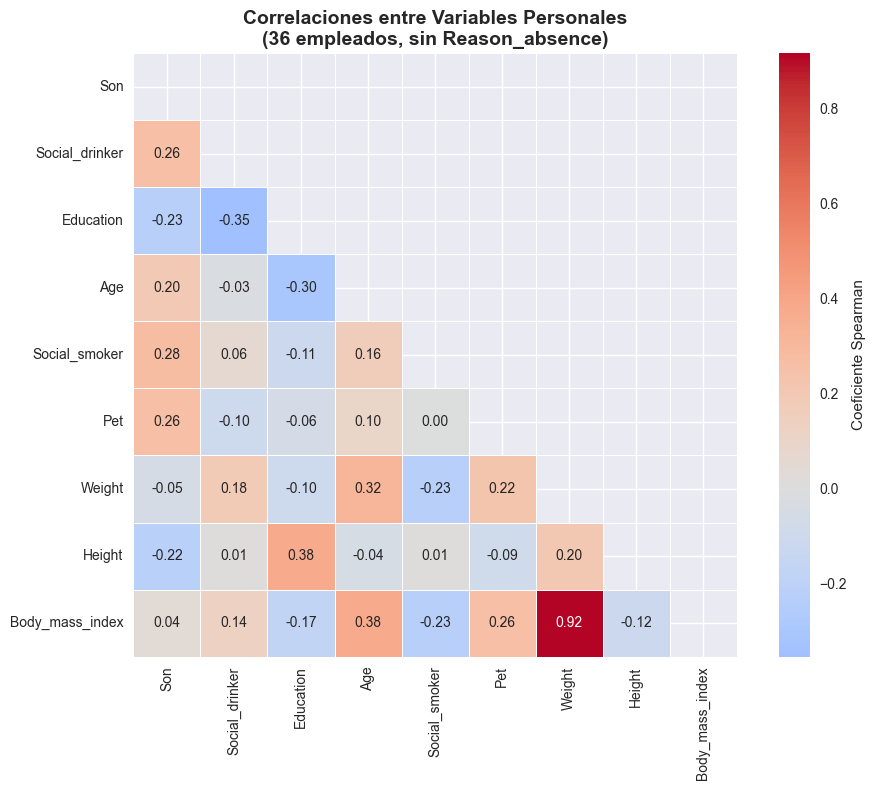


=== COMPARACIÓN PEARSON vs SPEARMAN ===


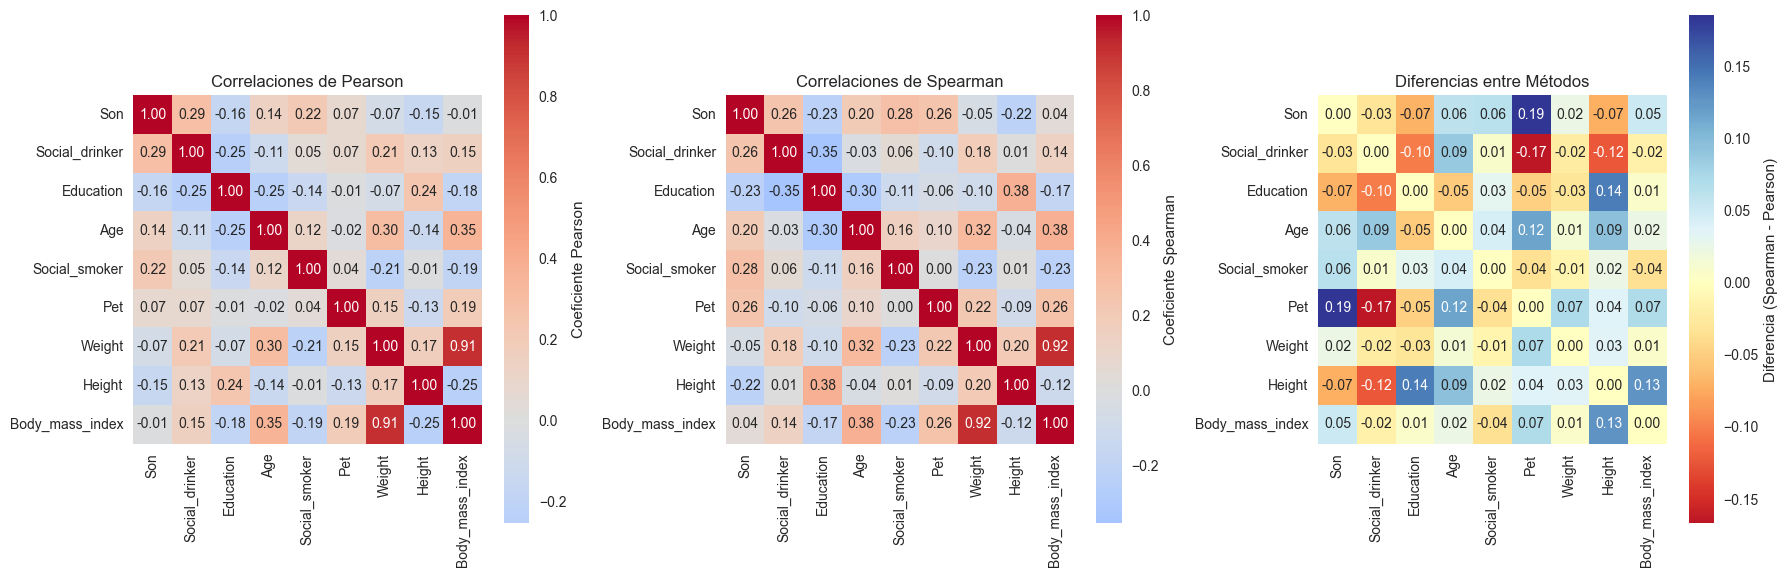


=== CORRELACIONES CON ABSENTISMO TOTAL ===
=== (Análisis más realista sin Reason_absence) ===
Correlaciones de Spearman con horas totales de absentismo:
(Interpretación: |ρ| < 0.3=Muy débil, 0.3-0.5=Débil, 0.5-0.7=Moderada, >0.7=Fuerte)
----------------------------------------------------------------------
  Son                  :   0.157 (MUY DÉBIL , positiva)
  Social_drinker       :   0.135 (MUY DÉBIL , positiva)
  Height               :  -0.031 (MUY DÉBIL , negativa)
  Weight               :  -0.064 (MUY DÉBIL , negativa)
  Body_mass_index      :  -0.065 (MUY DÉBIL , negativa)
  Education            :  -0.068 (MUY DÉBIL , negativa)
  Age                  :  -0.185 (MUY DÉBIL , negativa)
  Social_smoker        :  -0.206 (MUY DÉBIL , negativa)
  Pet                  :  -0.241 (MUY DÉBIL , negativa)


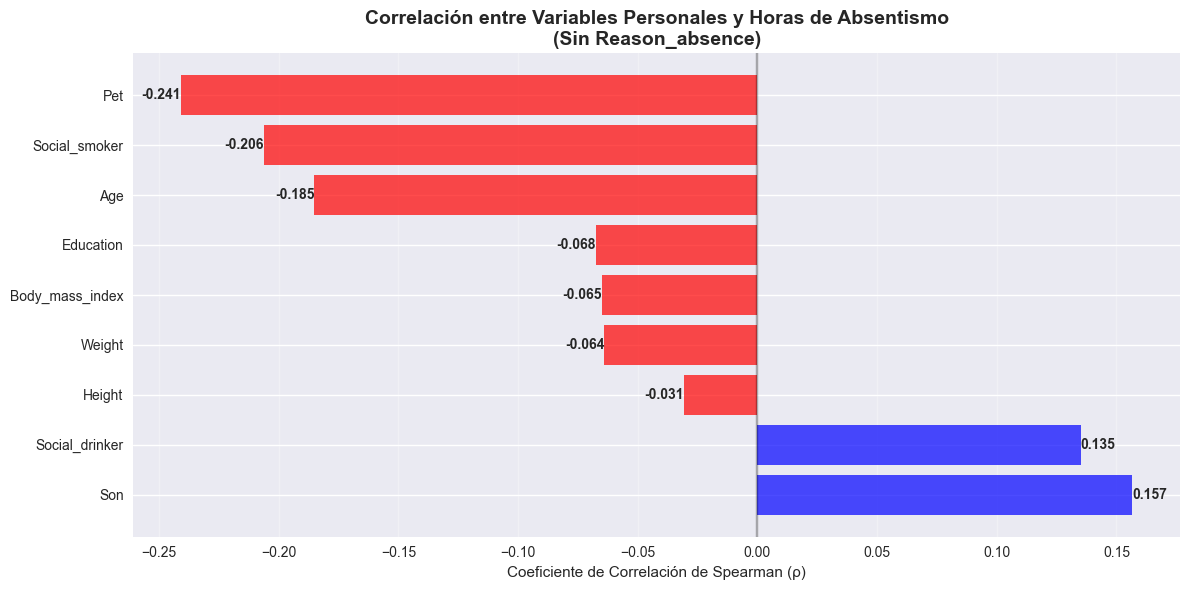


=== ANÁLISIS COMPLETADO CORRECTAMENTE ===
✅ Empleados analizados: 36
✅ Variables analizadas: 9
✅ Variable excluida: Reason_absence (para evitar bias)
✅ Mapas de codificación: ['Education']

📈 DISTRIBUCIÓN FINAL DE EDUCATION:
  High school: 28 empleados
  Graduate: 4 empleados
  Postgraduate: 3 empleados
  Master/Doctor: 1 empleados


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr
import pandas as pd

# 0. VERIFICAR ESTRUCTURA DEL DATASET
print("=== INFORMACIÓN DEL DATASET ===")
print(f"Total de filas en el dataset: {len(RRHH)}")
print(f"Columnas disponibles: {list(RRHH.columns)}")

# Buscar la columna ID (en mayúscula)
id_column = None
for col in RRHH.columns:
    if col == 'ID' or col == 'Id':
        id_column = col
        break

if id_column:
    print(f"Columna de ID encontrada: {id_column}")
    print(f"Número único de empleados: {RRHH[id_column].nunique()}")
else:
    print("No se encontró columna 'ID' - revisando otras opciones...")
    for col in RRHH.columns:
        if 'id' in col.lower() or 'employee' in col.lower() or 'empleado' in col.lower():
            id_column = col
            break
    
    if id_column:
        print(f"Columna de ID alternativa encontrada: {id_column}")
        print(f"Número único de empleados: {RRHH[id_column].nunique()}")
    else:
        print("No se encontró columna de ID - usando todas las filas como registros individuales")
        RRHH = RRHH.copy()
        RRHH['ID'] = range(1, len(RRHH) + 1)
        id_column = 'ID'

# 1. PREPROCESAMIENTO: CREAR DATASET ÚNICO POR EMPLEADO
print("\n=== CREANDO DATASET ÚNICO POR EMPLEADO ===")

# LISTA DE VARIABLES SIN Reason_absence (quitamos la variable que causa correlación artificial)
variables_personal = ['Son', 'Social_drinker', 'Education', 'Age', 
                     'Social_smoker', 'Pet', 'Weight', 'Height', 'Body_mass_index']  # Quitamos Reason_absence

print("🚫 Variable excluida: Reason_absence (para evitar correlación artificial)")

# Verificar qué variables existen
variables_existents = [var for var in variables_personal if var in RRHH.columns]
print(f"Variables analizadas: {variables_existents}")

# FUNCIÓN PARA OBTENER EL VALOR MÁS FRECUENTE POR EMPLEADO
def get_value_per_employee(df, id_col, variable_col):
    """Obtiene el valor representativo para cada empleado"""
    if df[variable_col].dtype in ['int64', 'float64']:
        # Para numéricos, usar el promedio
        result = df.groupby(id_col)[variable_col].mean().reset_index()
    else:
        # Para categóricos, usar la moda (valor más frecuente)
        moda_por_empleado = df.groupby(id_col)[variable_col].agg(
            lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0] if len(x) > 0 else np.nan
        )
        result = moda_por_empleado.reset_index()
    
    result.columns = [id_col, variable_col]
    return result

# Crear dataset único por empleado
empleados_unicos = RRHH[[id_column]].drop_duplicates()

print("Procesando variables por empleado...")
for var in variables_existents:
    if var in RRHH.columns:
        print(f"  - Procesando {var}...")
        var_data = get_value_per_employee(RRHH, id_column, var)
        empleados_unicos = empleados_unicos.merge(var_data, on=id_column, how='left')

print(f"✓ Dataset único creado con {len(empleados_unicos)} empleados")

# 2. CODIFICACIÓN DE VARIABLES CATEGÓRICAS
print("\n=== CODIFICACIÓN DE VARIABLES CATEGÓRICAS ===")

RRHH_codificado = empleados_unicos.drop(columns=[id_column]).copy()
encoding_maps = {}

# Identificar variables categóricas
variables_categoricas = []
for var in variables_existents:
    if var in RRHH_codificado.columns and RRHH_codificado[var].dtype not in ['int64', 'float64']:
        variables_categoricas.append(var)

print(f"Variables categóricas a codificar: {variables_categoricas}")

# CODIFICACIÓN DE EDUCATION
if 'Education' in RRHH_codificado.columns:
    print("\n--- Codificando Education ---")
    
    # Mostrar distribución original
    educ_distribucion = RRHH_codificado['Education'].value_counts()
    print("Distribución original de Education:")
    for valor, conteo in educ_distribucion.items():
        print(f"  {valor}: {conteo} empleados")
    
    # MAPEO CORREGIDO
    education_map = {
        'High school': 1,
        'Graduate': 2,
        'Postgraduate': 3, 
        'Master/Doctor': 4
    }
    
    # Verificar y completar mapeo
    educ_unique = RRHH_codificado['Education'].unique()
    for val in educ_unique:
        if pd.notna(val) and val not in education_map:
            print(f"⚠️  Valor no mapeado: '{val}' - asignando código {len(education_map) + 1}")
            education_map[val] = len(education_map) + 1
    
    RRHH_codificado['Education'] = RRHH_codificado['Education'].map(education_map)
    encoding_maps['Education'] = education_map
    
    print("✓ Education codificada")
    print(f"Mapa utilizado: {education_map}")

# Codificar otras variables categóricas
for var in variables_categoricas:
    if var != 'Education' and var in RRHH_codificado.columns:
        print(f"\n--- Codificando {var} ---")
        
        # Mostrar distribución original
        var_distribucion = RRHH_codificado[var].value_counts()
        print(f"Distribución original de {var}:")
        for valor, conteo in var_distribucion.items():
            print(f"  {valor}: {conteo} empleados")
        
        # Codificación simple
        unique_vals = RRHH_codificado[var].dropna().unique()
        encoding_map = {val: idx for idx, val in enumerate(unique_vals)}
        RRHH_codificado[var] = RRHH_codificado[var].map(encoding_map)
        encoding_maps[var] = encoding_map
        
        print(f"✓ {var} codificada")
        print(f"Mapa utilizado: {encoding_map}")

# 3. VERIFICACIÓN FINAL
print("\n=== VERIFICACIÓN FINAL ===")
print(f"Número real de empleados: {len(RRHH_codificado)}")

# Mostrar resumen CORRECTO de Education
if 'Education' in RRHH_codificado.columns:
    print(f"\n📊 DISTRIBUCIÓN REAL DE EDUCATION:")
    educ_counts = RRHH_codificado['Education'].value_counts().sort_index()
    total_empleados = len(RRHH_codificado)
    
    for codigo, count in educ_counts.items():
        # Encontrar el nombre del nivel educativo
        nivel_name = [k for k, v in education_map.items() if v == codigo]
        nombre = nivel_name[0] if nivel_name else f'Código {codigo}'
        porcentaje = (count / total_empleados) * 100
        print(f"  {nombre} ({codigo}): {count} empleados ({porcentaje:.1f}%)")

# 4. ANÁLISIS DE CORRELACIONES (SIN Reason_absence)
print("\n" + "="*60)
print("=== MATRIU DE CORRELACIONS DE SPEARMAN ===")
print("=== (Sin Reason_absence para evitar bias) ===")
print("="*60)

# Identificar variables numéricas finales
variables_numericas = []
for var in variables_existents:
    if var in RRHH_codificado.columns and RRHH_codificado[var].dtype in ['int64', 'float64']:
        variables_numericas.append(var)

print(f"Variables analizadas: {variables_numericas}")
print(f"Tamaño del dataset: {len(RRHH_codificado)} empleados")

if len(variables_numericas) > 1:
    # Convertir a numérico y manejar NaN
    for var in variables_numericas:
        RRHH_codificado[var] = pd.to_numeric(RRHH_codificado[var], errors='coerce')
    
    # Verificar valores faltantes
    print("\nValores faltantes por variable:")
    for var in variables_numericas:
        n_missing = RRHH_codificado[var].isna().sum()
        if n_missing > 0:
            print(f"  {var}: {n_missing} faltantes ({n_missing/len(RRHH_codificado)*100:.1f}%)")
    
    # Calcular matriz de correlaciones
    try:
        correlacions_spearman = RRHH_codificado[variables_numericas].corr(method='spearman')
        
        # Visualización
        plt.figure(figsize=(10, 8))
        mask = np.triu(np.ones_like(correlacions_spearman, dtype=bool))
        sns.heatmap(correlacions_spearman, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
                    square=True, linewidths=0.5, mask=mask, cbar_kws={'label': 'Coeficiente Spearman'})
        plt.title(f'Correlaciones entre Variables Personales\n({len(RRHH_codificado)} empleados, sin Reason_absence)', 
                  fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # 5. COMPARACIÓN PEARSON vs SPEARMAN
        print("\n=== COMPARACIÓN PEARSON vs SPEARMAN ===")
        
        correlacions_pearson = RRHH_codificado[variables_numericas].corr(method='pearson')
        diferencies = correlacions_spearman - correlacions_pearson

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # Pearson
        sns.heatmap(correlacions_pearson, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
                    square=True, ax=axes[0], cbar_kws={'label': 'Coeficiente Pearson'})
        axes[0].set_title('Correlaciones de Pearson')

        # Spearman
        sns.heatmap(correlacions_spearman, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
                    square=True, ax=axes[1], cbar_kws={'label': 'Coeficiente Spearman'})
        axes[1].set_title('Correlaciones de Spearman')

        # Diferencias
        sns.heatmap(diferencies, annot=True, cmap='RdYlBu', center=0, fmt='.2f', 
                    square=True, ax=axes[2], cbar_kws={'label': 'Diferencia (Spearman - Pearson)'})
        axes[2].set_title('Diferencias entre Métodos')

        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error en cálculo de correlaciones: {e}")
    
    # 6. CORRELACIONES CON ABSENTISMO (SIN Reason_absence)
    if 'Absenteeism_hours' in RRHH.columns:
        print("\n=== CORRELACIONES CON ABSENTISMO TOTAL ===")
        print("=== (Análisis más realista sin Reason_absence) ===")
        
        # Calcular horas de absentismo por empleado (SUMA total)
        absentismo_por_empleado = RRHH.groupby(id_column)['Absenteeism_hours'].sum().reset_index()
        absentismo_por_empleado.columns = [id_column, 'Absenteeism_hours_total']
        
        # Unir con el dataset de empleados
        RRHH_analisis = empleados_unicos.merge(absentismo_por_empleado, on=id_column, how='left')
        
        # Codificar variables categóricas en el dataset de análisis
        for var, mapping in encoding_maps.items():
            if var in RRHH_analisis.columns:
                RRHH_analisis[var] = RRHH_analisis[var].map(mapping)
        
        # Variables numéricas para análisis con absentismo (SIN Reason_absence)
        vars_analisis = variables_numericas + ['Absenteeism_hours_total']
        vars_analisis = [var for var in vars_analisis if var in RRHH_analisis.columns]
        
        try:
            correlaciones_abs = RRHH_analisis[vars_analisis].corr(method='spearman')
            
            if 'Absenteeism_hours_total' in correlaciones_abs.columns:
                corr_con_absentismo = correlaciones_abs['Absenteeism_hours_total'].drop('Absenteeism_hours_total').sort_values(ascending=False)
                
                print("Correlaciones de Spearman con horas totales de absentismo:")
                print("(Interpretación: |ρ| < 0.3=Muy débil, 0.3-0.5=Débil, 0.5-0.7=Moderada, >0.7=Fuerte)")
                print("-" * 70)
                
                for var, corr in corr_con_absentismo.items():
                    if abs(corr) >= 0.7:
                        fuerza = "FUERTE"
                    elif abs(corr) >= 0.5:
                        fuerza = "MODERADA" 
                    elif abs(corr) >= 0.3:
                        fuerza = "DÉBIL"
                    else:
                        fuerza = "MUY DÉBIL"
                    signo = "positiva" if corr > 0 else "negativa"
                    print(f"  {var:20} : {corr:7.3f} ({fuerza:10}, {signo})")
                
                # Gráfico de correlaciones con absentismo
                if len(corr_con_absentismo) > 0:
                    plt.figure(figsize=(12, 6))
                    bars = plt.barh(range(len(corr_con_absentismo)), corr_con_absentismo.values, 
                                   color=['red' if x < 0 else 'blue' for x in corr_con_absentismo.values], alpha=0.7)
                    
                    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
                    plt.yticks(range(len(corr_con_absentismo)), corr_con_absentismo.index)
                    plt.xlabel('Coeficiente de Correlación de Spearman (ρ)')
                    plt.title('Correlación entre Variables Personales y Horas de Absentismo\n(Sin Reason_absence)', 
                             fontsize=14, fontweight='bold')
                    
                    # Añadir valores en las barras
                    for bar in bars:
                        width = bar.get_width()
                        plt.text(width, bar.get_y() + bar.get_height()/2, 
                                f'{width:.3f}', ha='left' if width >= 0 else 'right', 
                                va='center', fontweight='bold')
                    
                    plt.grid(axis='x', alpha=0.3)
                    plt.tight_layout()
                    plt.show()
                    
        except Exception as e:
            print(f"Error en correlaciones con absentismo: {e}")

else:
    print("No hay suficientes variables numéricas para el análisis")

print("\n" + "="*70)
print("=== ANÁLISIS COMPLETADO CORRECTAMENTE ===")
print("="*70)
print(f"✅ Empleados analizados: {len(empleados_unicos)}")
print(f"✅ Variables analizadas: {len(variables_numericas)}")
print(f"✅ Variable excluida: Reason_absence (para evitar bias)")
print(f"✅ Mapas de codificación: {list(encoding_maps.keys())}")

# Mostrar estadísticas finales
if 'Education' in encoding_maps:
    print(f"\n📈 DISTRIBUCIÓN FINAL DE EDUCATION:")
    educ_counts = RRHH_codificado['Education'].value_counts().sort_index()
    for codigo, count in educ_counts.items():
        nivel_name = [k for k, v in education_map.items() if v == codigo]
        nombre = nivel_name[0] if nivel_name else f'Código {codigo}'
        print(f"  {nombre}: {count} empleados")

=== INFORMACIÓN DEL DATASET ===
Total de filas en el dataset: 706
Columnas disponibles: ['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons', 'Transportation_expense', 'Distance_Residence_Work', 'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure', 'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height', 'Body_mass_index', 'Absenteeism_hours', 'Education_numeric', 'Month_absence_order', 'Day_week_order', 'Seasons_order']
Columna de ID encontrada: ID
Número único de empleados: 36

=== CREANDO DATASET ÚNICO POR EMPLEADO ===
🚫 Variable excluida: Reason_absence (para evitar correlación artificial)
Variables laborales analizadas: ['Seasons', 'Disciplinary_failure', 'Service_time', 'Work_load_Average_day', 'Hit_target', 'Transportation_expense']
Procesando variables laborales por empleado...
  - Procesando Seasons...
  - Procesando Disciplinary_failure...
  - Procesando Service_time...
  - Procesando Work_load_Average_day...

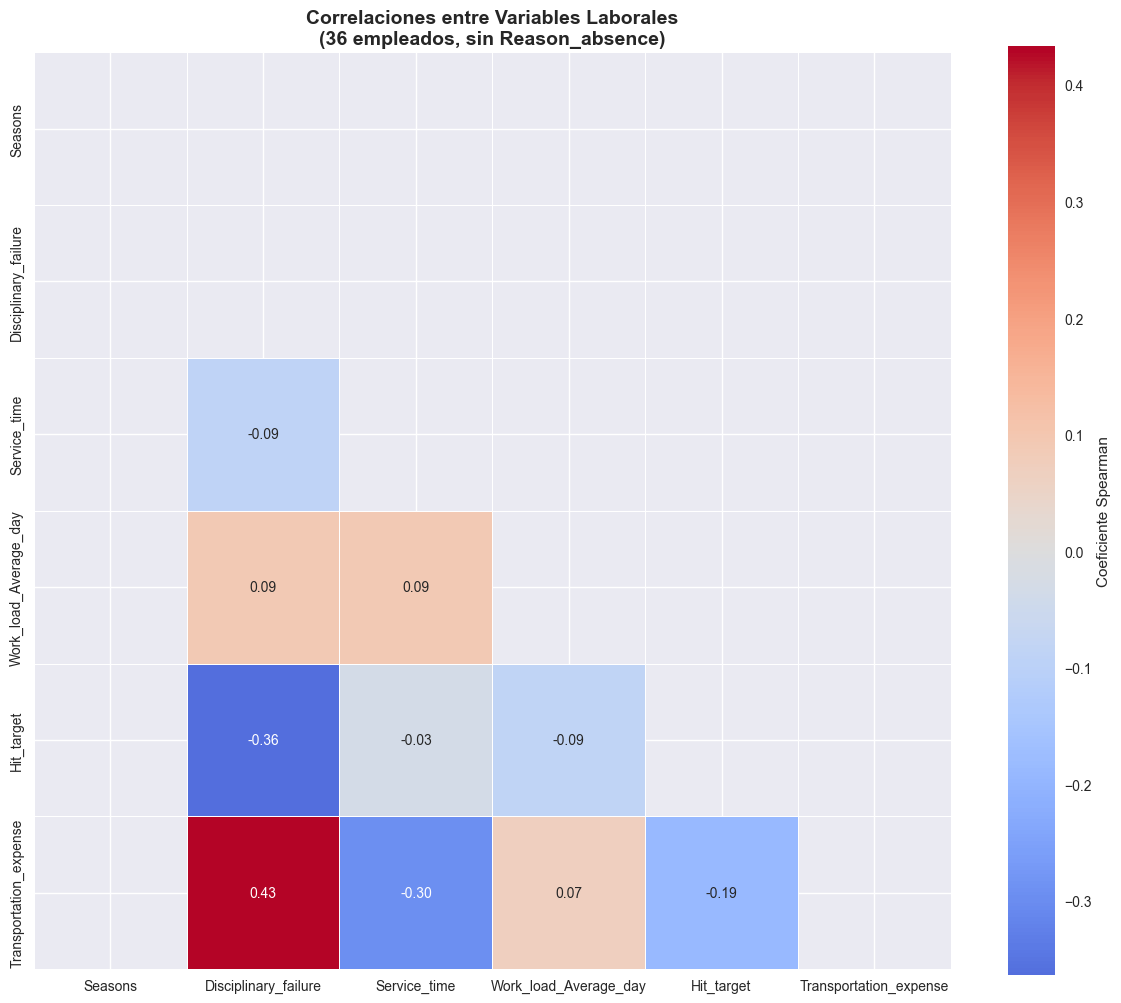


=== COMPARACIÓN PEARSON vs SPEARMAN ===


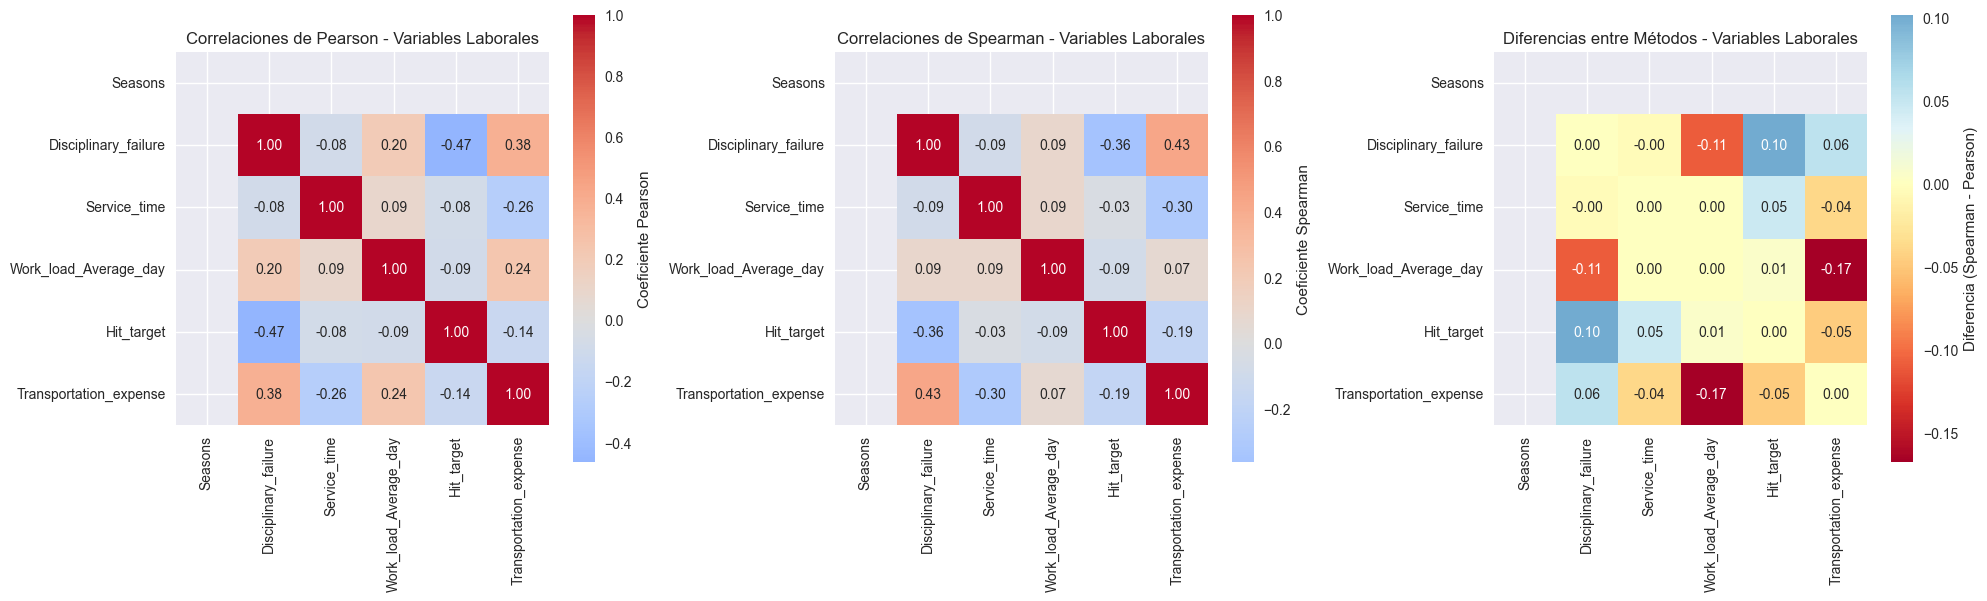

posx and posy should be finite values
posx and posy should be finite values



=== CORRELACIONES LABORALES CON ABSENTISMO TOTAL ===
=== (Análisis variables laborales vs absentismo) ===
Correlaciones de Spearman - Variables Laborales vs Absentismo:
(Interpretación: |ρ| < 0.3=Muy débil, 0.3-0.5=Débil, 0.5-0.7=Moderada, >0.7=Fuerte)
--------------------------------------------------------------------------------
  Service_time                   :   0.052 (MUY DÉBIL , positiva) (Tiempo de servicio)
  Hit_target                     :  -0.028 (MUY DÉBIL , negativa) (Cumplimiento objetivos)
  Work_load_Average_day          :  -0.029 (MUY DÉBIL , negativa) (Carga de trabajo)
  Transportation_expense         :  -0.074 (MUY DÉBIL , negativa) (Gastos transporte)
  Disciplinary_failure           :  -0.215 (MUY DÉBIL , negativa)
  Seasons                        :     nan (MUY DÉBIL , negativa)


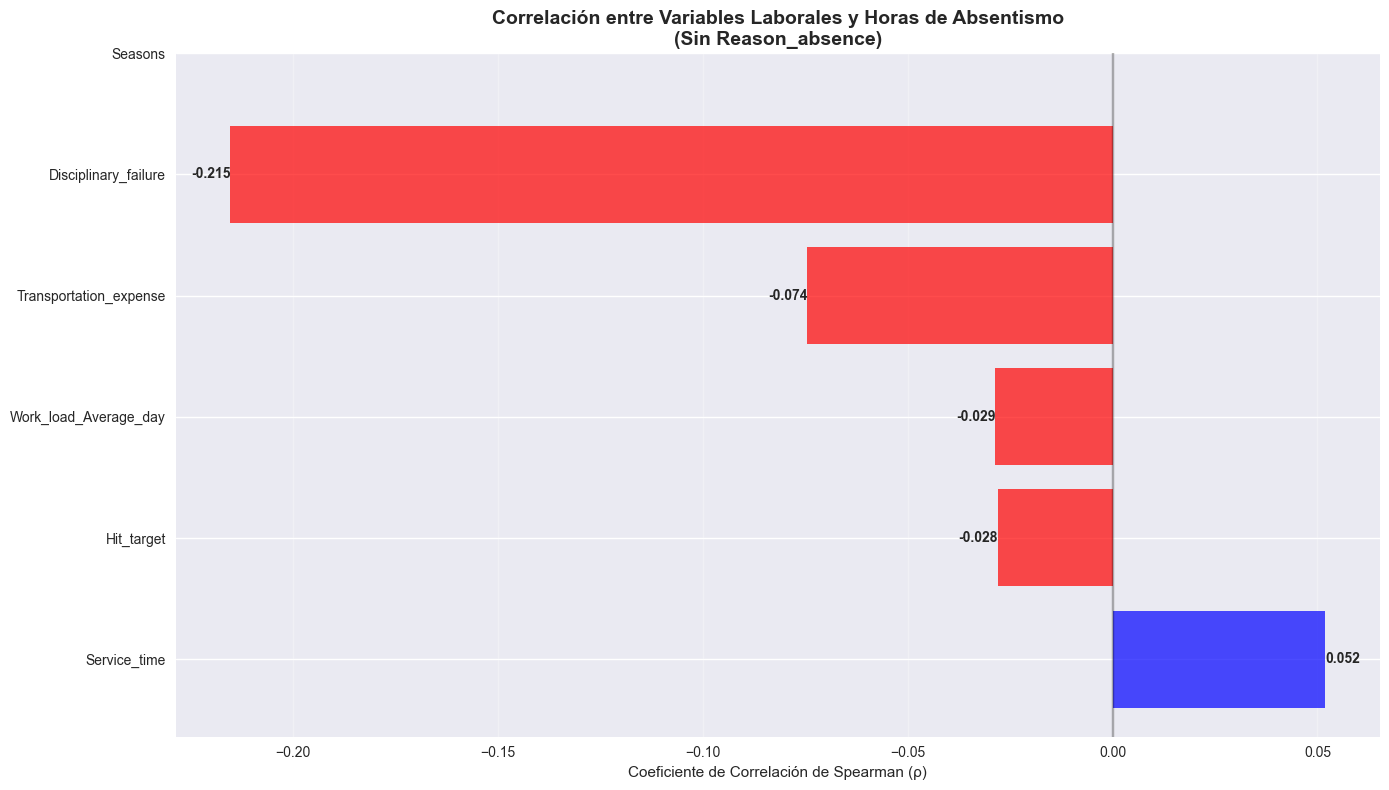


=== ANÁLISIS POR CATEGORÍAS DE ABSENTISMO - VARIABLES LABORALES ===

📊 PERFIL LABORAL POR CATEGORÍA DE ABSENTISMO:
------------------------------------------------------------

🎯 Bajo ABSENTISMO (1 empleados):
----------------------------------------
💼 VARIABLES LABORALES:
  • Tiempo de servicio promedio: 12.0 años
  • Carga de trabajo promedio: 281.1
  • Cumplimiento de objetivos: 89.3%
  • Gastos de transporte: $291.0

⏰ ABSENTISMO:
  • Horas totales: 6
  • Promedio por empleado: 6.0 horas

🎯 Moderado ABSENTISMO (12 empleados):
----------------------------------------
💼 VARIABLES LABORALES:
  • Tiempo de servicio promedio: 11.9 años
  • Carga de trabajo promedio: 276.8
  • Cumplimiento de objetivos: 95.2%
  • Gastos de transporte: $249.1

⏰ ABSENTISMO:
  • Horas totales: 312
  • Promedio por empleado: 26.0 horas

🎯 Alto ABSENTISMO (3 empleados):
----------------------------------------
💼 VARIABLES LABORALES:
  • Tiempo de servicio promedio: 13.3 años
  • Carga de trabajo promedio: 2

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr
import pandas as pd

# 0. VERIFICAR ESTRUCTURA DEL DATASET
print("=== INFORMACIÓN DEL DATASET ===")
print(f"Total de filas en el dataset: {len(RRHH)}")
print(f"Columnas disponibles: {list(RRHH.columns)}")

# Buscar la columna ID (en mayúscula)
id_column = None
for col in RRHH.columns:
    if col == 'ID' or col == 'Id':
        id_column = col
        break

if id_column:
    print(f"Columna de ID encontrada: {id_column}")
    print(f"Número único de empleados: {RRHH[id_column].nunique()}")
else:
    print("No se encontró columna 'ID' - revisando otras opciones...")
    for col in RRHH.columns:
        if 'id' in col.lower() or 'employee' in col.lower() or 'empleado' in col.lower():
            id_column = col
            break
    
    if id_column:
        print(f"Columna de ID alternativa encontrada: {id_column}")
        print(f"Número único de empleados: {RRHH[id_column].nunique()}")
    else:
        print("No se encontró columna de ID - usando todas las filas como registros individuales")
        RRHH = RRHH.copy()
        RRHH['ID'] = range(1, len(RRHH) + 1)
        id_column = 'ID'

# 1. PREPROCESAMIENTO: CREAR DATASET ÚNICO POR EMPLEADO
print("\n=== CREANDO DATASET ÚNICO POR EMPLEADO ===")

# LISTA DE VARIABLES LABORALES (excluyendo Reason_absence)
variables_laborales = [
    'Department', 'Month_of_absence', 'Day_of_the_week', 'Seasons', 
    'Disciplinary_failure', 'Service_time', 'Work_load_Average_day', 
    'Hit_target', 'Transportation_expense', 'Distance_from_Residence_to_Work'
]

print("🚫 Variable excluida: Reason_absence (para evitar correlación artificial)")

# Verificar qué variables laborales existen
variables_existents = [var for var in variables_laborales if var in RRHH.columns]
print(f"Variables laborales analizadas: {variables_existents}")

# FUNCIÓN PARA OBTENER EL VALOR MÁS FRECUENTE POR EMPLEADO
def get_value_per_employee(df, id_col, variable_col):
    """Obtiene el valor representativo para cada empleado"""
    if df[variable_col].dtype in ['int64', 'float64']:
        # Para numéricos laborales, usar el promedio (ej: carga de trabajo, tiempo de servicio)
        result = df.groupby(id_col)[variable_col].mean().reset_index()
    else:
        # Para categóricos laborales, usar la moda (valor más frecuente)
        moda_por_empleado = df.groupby(id_col)[variable_col].agg(
            lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0] if len(x) > 0 else np.nan
        )
        result = moda_por_empleado.reset_index()
    
    result.columns = [id_col, variable_col]
    return result

# Crear dataset único por empleado
empleados_unicos = RRHH[[id_column]].drop_duplicates()

print("Procesando variables laborales por empleado...")
for var in variables_existents:
    if var in RRHH.columns:
        print(f"  - Procesando {var}...")
        var_data = get_value_per_employee(RRHH, id_column, var)
        empleados_unicos = empleados_unicos.merge(var_data, on=id_column, how='left')

print(f"✓ Dataset único creado con {len(empleados_unicos)} empleados")

# 2. CODIFICACIÓN DE VARIABLES CATEGÓRICAS LABORALES
print("\n=== CODIFICACIÓN DE VARIABLES CATEGÓRICAS LABORALES ===")

RRHH_codificado = empleados_unicos.drop(columns=[id_column]).copy()
encoding_maps = {}

# Identificar variables categóricas laborales
variables_categoricas = []
for var in variables_existents:
    if var in RRHH_codificado.columns and RRHH_codificado[var].dtype not in ['int64', 'float64']:
        variables_categoricas.append(var)

print(f"Variables categóricas laborales a codificar: {variables_categoricas}")

# CODIFICACIÓN ESPECÍFICA PARA VARIABLES LABORALES
if 'Department' in RRHH_codificado.columns:
    print("\n--- Codificando Department ---")
    
    # Mostrar distribución original
    dept_distribucion = RRHH_codificado['Department'].value_counts()
    print("Distribución original de Department:")
    for valor, conteo in dept_distribucion.items():
        print(f"  {valor}: {conteo} empleados")
    
    # Codificación ordinal basada en tamaño del departamento (opcional)
    department_map = {dept: idx for idx, dept in enumerate(dept_distribucion.index)}
    RRHH_codificado['Department'] = RRHH_codificado['Department'].map(department_map)
    encoding_maps['Department'] = department_map
    print("✓ Department codificado")
    print(f"Mapa utilizado: {department_map}")

if 'Seasons' in RRHH_codificado.columns:
    print("\n--- Codificando Seasons ---")
    
    # Codificación ordinal para estaciones (primavera=1, verano=2, etc.)
    seasons_map = {'Spring': 1, 'Summer': 2, 'Autumn': 3, 'Winter': 4}
    RRHH_codificado['Seasons'] = RRHH_codificado['Seasons'].map(seasons_map)
    encoding_maps['Seasons'] = seasons_map
    print("✓ Seasons codificado")
    print(f"Mapa utilizado: {seasons_map}")

if 'Day_of_the_week' in RRHH_codificado.columns:
    print("\n--- Codificando Day_of_the_week ---")
    
    # Codificación ordinal para días de la semana
    day_map = {'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4, 'Friday': 5}
    RRHH_codificado['Day_of_the_week'] = RRHH_codificado['Day_of_the_week'].map(day_map)
    encoding_maps['Day_of_the_week'] = day_map
    print("✓ Day_of_the_week codificado")
    print(f"Mapa utilizado: {day_map}")

# Codificar otras variables categóricas laborales
for var in variables_categoricas:
    if var not in ['Department', 'Seasons', 'Day_of_the_week'] and var in RRHH_codificado.columns:
        print(f"\n--- Codificando {var} ---")
        
        # Mostrar distribución original
        var_distribucion = RRHH_codificado[var].value_counts()
        print(f"Distribución original de {var}:")
        for valor, conteo in var_distribucion.items():
            print(f"  {valor}: {conteo} empleados")
        
        # Codificación simple
        unique_vals = RRHH_codificado[var].dropna().unique()
        encoding_map = {val: idx for idx, val in enumerate(unique_vals)}
        RRHH_codificado[var] = RRHH_codificado[var].map(encoding_map)
        encoding_maps[var] = encoding_map
        
        print(f"✓ {var} codificada")
        print(f"Mapa utilizado: {encoding_map}")

# 3. VERIFICACIÓN FINAL
print("\n=== VERIFICACIÓN FINAL ===")
print(f"Número real de empleados: {len(RRHH_codificado)}")

# Mostrar resumen de variables laborales clave
if 'Department' in encoding_maps:
    print(f"\n📊 DISTRIBUCIÓN DE DEPARTAMENTOS:")
    dept_counts = RRHH_codificado['Department'].value_counts().sort_index()
    total_empleados = len(RRHH_codificado)
    
    for codigo, count in dept_counts.items():
        dept_name = [k for k, v in encoding_maps['Department'].items() if v == codigo]
        nombre = dept_name[0] if dept_name else f'Departamento {codigo}'
        porcentaje = (count / total_empleados) * 100
        print(f"  {nombre}: {count} empleados ({porcentaje:.1f}%)")

# 4. ANÁLISIS DE CORRELACIONES LABORALES (SIN Reason_absence)
print("\n" + "="*60)
print("=== MATRIZ DE CORRELACIONES DE SPEARMAN - VARIABLES LABORALES ===")
print("=== (Sin Reason_absence para evitar bias) ===")
print("="*60)

# Identificar variables numéricas finales
variables_numericas = []
for var in variables_existents:
    if var in RRHH_codificado.columns and RRHH_codificado[var].dtype in ['int64', 'float64']:
        variables_numericas.append(var)

print(f"Variables laborales analizadas: {variables_numericas}")
print(f"Tamaño del dataset: {len(RRHH_codificado)} empleados")

if len(variables_numericas) > 1:
    # Convertir a numérico y manejar NaN
    for var in variables_numericas:
        RRHH_codificado[var] = pd.to_numeric(RRHH_codificado[var], errors='coerce')
    
    # Verificar valores faltantes
    print("\nValores faltantes por variable laboral:")
    for var in variables_numericas:
        n_missing = RRHH_codificado[var].isna().sum()
        if n_missing > 0:
            print(f"  {var}: {n_missing} faltantes ({n_missing/len(RRHH_codificado)*100:.1f}%)")
    
    # Calcular matriz de correlaciones laborales
    try:
        correlacions_spearman = RRHH_codificado[variables_numericas].corr(method='spearman')
        
        # Visualización
        plt.figure(figsize=(12, 10))
        mask = np.triu(np.ones_like(correlacions_spearman, dtype=bool))
        sns.heatmap(correlacions_spearman, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
                    square=True, linewidths=0.5, mask=mask, cbar_kws={'label': 'Coeficiente Spearman'})
        plt.title(f'Correlaciones entre Variables Laborales\n({len(RRHH_codificado)} empleados, sin Reason_absence)', 
                  fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # 5. COMPARACIÓN PEARSON vs SPEARMAN
        print("\n=== COMPARACIÓN PEARSON vs SPEARMAN ===")
        
        correlacions_pearson = RRHH_codificado[variables_numericas].corr(method='pearson')
        diferencies = correlacions_spearman - correlacions_pearson

        fig, axes = plt.subplots(1, 3, figsize=(20, 6))

        # Pearson
        sns.heatmap(correlacions_pearson, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
                    square=True, ax=axes[0], cbar_kws={'label': 'Coeficiente Pearson'})
        axes[0].set_title('Correlaciones de Pearson - Variables Laborales')

        # Spearman
        sns.heatmap(correlacions_spearman, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
                    square=True, ax=axes[1], cbar_kws={'label': 'Coeficiente Spearman'})
        axes[1].set_title('Correlaciones de Spearman - Variables Laborales')

        # Diferencias
        sns.heatmap(diferencies, annot=True, cmap='RdYlBu', center=0, fmt='.2f', 
                    square=True, ax=axes[2], cbar_kws={'label': 'Diferencia (Spearman - Pearson)'})
        axes[2].set_title('Diferencias entre Métodos - Variables Laborales')

        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error en cálculo de correlaciones laborales: {e}")
    
    # 6. CORRELACIONES LABORALES CON ABSENTISMO
    if 'Absenteeism_hours' in RRHH.columns:
        print("\n=== CORRELACIONES LABORALES CON ABSENTISMO TOTAL ===")
        print("=== (Análisis variables laborales vs absentismo) ===")
        
        # Calcular horas de absentismo por empleado (SUMA total)
        absentismo_por_empleado = RRHH.groupby(id_column)['Absenteeism_hours'].sum().reset_index()
        absentismo_por_empleado.columns = [id_column, 'Absenteeism_hours_total']
        
        # Unir con el dataset de empleados
        RRHH_analisis = empleados_unicos.merge(absentismo_por_empleado, on=id_column, how='left')
        
        # Codificar variables categóricas laborales en el dataset de análisis
        for var, mapping in encoding_maps.items():
            if var in RRHH_analisis.columns:
                RRHH_analisis[var] = RRHH_analisis[var].map(mapping)
        
        # Variables laborales para análisis con absentismo
        vars_analisis = variables_numericas + ['Absenteeism_hours_total']
        vars_analisis = [var for var in vars_analisis if var in RRHH_analisis.columns]
        
        try:
            correlaciones_abs = RRHH_analisis[vars_analisis].corr(method='spearman')
            
            if 'Absenteeism_hours_total' in correlaciones_abs.columns:
                corr_con_absentismo = correlaciones_abs['Absenteeism_hours_total'].drop('Absenteeism_hours_total').sort_values(ascending=False)
                
                print("Correlaciones de Spearman - Variables Laborales vs Absentismo:")
                print("(Interpretación: |ρ| < 0.3=Muy débil, 0.3-0.5=Débil, 0.5-0.7=Moderada, >0.7=Fuerte)")
                print("-" * 80)
                
                for var, corr in corr_con_absentismo.items():
                    if abs(corr) >= 0.7:
                        fuerza = "FUERTE"
                    elif abs(corr) >= 0.5:
                        fuerza = "MODERADA" 
                    elif abs(corr) >= 0.3:
                        fuerza = "DÉBIL"
                    else:
                        fuerza = "MUY DÉBIL"
                    signo = "positiva" if corr > 0 else "negativa"
                    
                    # Interpretación específica para variables laborales
                    interpretacion = ""
                    if var == 'Service_time':
                        interpretacion = " (Tiempo de servicio)" 
                    elif var == 'Work_load_Average_day':
                        interpretacion = " (Carga de trabajo)"
                    elif var == 'Hit_target':
                        interpretacion = " (Cumplimiento objetivos)"
                    elif var == 'Transportation_expense':
                        interpretacion = " (Gastos transporte)"
                    elif var == 'Distance_from_Residence_to_Work':
                        interpretacion = " (Distancia al trabajo)"
                    
                    print(f"  {var:30} : {corr:7.3f} ({fuerza:10}, {signo}){interpretacion}")
                
                # Gráfico de correlaciones laborales con absentismo
                if len(corr_con_absentismo) > 0:
                    plt.figure(figsize=(14, 8))
                    bars = plt.barh(range(len(corr_con_absentismo)), corr_con_absentismo.values, 
                                   color=['red' if x < 0 else 'blue' for x in corr_con_absentismo.values], alpha=0.7)
                    
                    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
                    plt.yticks(range(len(corr_con_absentismo)), corr_con_absentismo.index)
                    plt.xlabel('Coeficiente de Correlación de Spearman (ρ)')
                    plt.title('Correlación entre Variables Laborales y Horas de Absentismo\n(Sin Reason_absence)', 
                             fontsize=14, fontweight='bold')
                    
                    # Añadir valores en las barras
                    for bar in bars:
                        width = bar.get_width()
                        plt.text(width, bar.get_y() + bar.get_height()/2, 
                                f'{width:.3f}', ha='left' if width >= 0 else 'right', 
                                va='center', fontweight='bold')
                    
                    plt.grid(axis='x', alpha=0.3)
                    plt.tight_layout()
                    plt.show()
                    
        except Exception as e:
            print(f"Error en correlaciones laborales con absentismo: {e}")

else:
    print("No hay suficientes variables laborales numéricas para el análisis")

# 7. ANÁLISIS POR CATEGORÍAS DE ABSENTISMO - VARIABLES LABORALES
if 'Absenteeism_hours' in RRHH.columns and 'RRHH_analisis' in locals():
    print("\n" + "="*70)
    print("=== ANÁLISIS POR CATEGORÍAS DE ABSENTISMO - VARIABLES LABORALES ===")
    print("="*70)
    
    # Crear categorías de absentismo
    RRHH_analisis['Absenteeism_category'] = pd.cut(RRHH_analisis['Absenteeism_hours_total'], 
                                                  bins=[0, 10, 50, 100, 1000], 
                                                  labels=['Bajo', 'Moderado', 'Alto', 'Muy Alto'])
    
    # Variables laborales clave para análisis
    variables_laborales_clave = ['Service_time', 'Work_load_Average_day', 'Hit_target', 
                                'Transportation_expense', 'Distance_from_Residence_to_Work']
    variables_laborales_clave = [var for var in variables_laborales_clave if var in RRHH_analisis.columns]
    
    print("\n📊 PERFIL LABORAL POR CATEGORÍA DE ABSENTISMO:")
    print("-" * 60)
    
    for category in ['Bajo', 'Moderado', 'Alto', 'Muy Alto']:
        subset = RRHH_analisis[RRHH_analisis['Absenteeism_category'] == category]
        if len(subset) > 0:
            print(f"\n🎯 {category} ABSENTISMO ({len(subset)} empleados):")
            print("-" * 40)
            
            print("💼 VARIABLES LABORALES:")
            if 'Service_time' in subset.columns:
                print(f"  • Tiempo de servicio promedio: {subset['Service_time'].mean():.1f} años")
            if 'Work_load_Average_day' in subset.columns:
                print(f"  • Carga de trabajo promedio: {subset['Work_load_Average_day'].mean():.1f}")
            if 'Hit_target' in subset.columns:
                print(f"  • Cumplimiento de objetivos: {subset['Hit_target'].mean():.1f}%")
            if 'Transportation_expense' in subset.columns:
                print(f"  • Gastos de transporte: ${subset['Transportation_expense'].mean():.1f}")
            if 'Distance_from_Residence_to_Work' in subset.columns:
                print(f"  • Distancia al trabajo: {subset['Distance_from_Residence_to_Work'].mean():.1f} km")
            
            print(f"\n⏰ ABSENTISMO:")
            print(f"  • Horas totales: {subset['Absenteeism_hours_total'].sum():.0f}")
            print(f"  • Promedio por empleado: {subset['Absenteeism_hours_total'].mean():.1f} horas")

print("\n" + "="*70)
print("=== ANÁLISIS LABORAL COMPLETADO ===")
print("="*70)
print(f"✅ Empleados analizados: {len(empleados_unicos)}")
print(f"✅ Variables laborales analizadas: {len(variables_numericas)}")
print(f"✅ Variable excluida: Reason_absence (para evitar bias)")
print(f"✅ Mapas de codificación: {list(encoding_maps.keys())}")